# Does crossing the ring road mean a longer Vélib’ ride?

**Author** : Palatine Rigaut

**Date** : October 2025

## 1. Problem

In Paris, bike-sharing has become an essential part of urban mobility, connecting the city with its surrounding suburbs. The ring-road (“périphérique”) is often seen as a symbolic and physical border between Paris and the rest of the metropolitan area.

**Do Vélib' trips that cross the Paris ring road last longer, as we might expect?**

To answer this question, I will focus on the duration of Vélib' trips recorded over a sufficiently long time interval.

## 2. Library import

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 3. Data import

We use data from velibest.fr, recorded continuously for about one hour on October 11, 2025, and updated about every minute.

In [15]:
df_events = pd.read_csv("velib_events.csv")
display(df_events)

,hour,station_id,station_name,bike_id,action
0,14:53:00,station_22201,henri ravera gabriel peri,bike_79454,undock
1,14:53:00,station_23201,avenir,bike_43704,undock
2,14:53:00,station_42301,gare arcueil cachan,bike_82803,dock
3,14:53:00,station_22208,stalingrad barbara,bike_46152,dock
4,14:53:00,station_44002,paul vaillant couturier gare rer,bike_52173,undock
...,...,...,...,...,...
84636,19:18:54,station_19005,flandre riquet,bike_24197,undock
84637,19:18:54,station_19005,flandre riquet,bike_46391,dock
84638,19:18:54,station_19125,place de l edit de nantes,bike_21821,undock
84639,19:18:54,station_19002,centquatre,bike_33061,dock


We also use a complementary dataset listing every Vélib' station, along with its latitude, longitude, and a flag indicating if the station is located inside the ring road or not.

In [16]:
df_stations = pd.read_csv("stations.csv")
display(df_stations)

,station_id,name,lat,lon,capacity,is_paris
0,213688169,benjamin godard victor hugo,48.865983,2.275725,35.0,1
1,19179944124,hopital mondor,48.798922,2.453745,28.0,0
2,18795078746,charcot benfleet,48.878370,2.440524,28.0,0
3,36255,toudouze clauzel,48.879296,2.337360,21.0,1
4,251039991,cassini denfert rochereau,48.837526,2.336035,25.0,1
...,...,...,...,...,...,...
1488,20084863816,arbalete claude bernard,48.840009,2.347523,34.0,1
1489,101013666,bercy villot,48.841795,2.376785,33.0,1
1490,34742973,place balard,48.836396,2.278419,22.0,1
1491,315022587,malesherbes place de la madeleine,48.870406,2.323244,67.0,1


## 4. Dataset merge

In [17]:
lookup = df_stations.set_index("name")[["is_paris"]]
df = df_events.join(lookup, on="station_name")
display(df)

,hour,station_id,station_name,bike_id,action,is_paris
0,14:53:00,station_22201,henri ravera gabriel peri,bike_79454,undock,0
1,14:53:00,station_23201,avenir,bike_43704,undock,0
2,14:53:00,station_42301,gare arcueil cachan,bike_82803,dock,0
3,14:53:00,station_22208,stalingrad barbara,bike_46152,dock,0
4,14:53:00,station_44002,paul vaillant couturier gare rer,bike_52173,undock,0
...,...,...,...,...,...,...
84636,19:18:54,station_19005,flandre riquet,bike_24197,undock,1
84637,19:18:54,station_19005,flandre riquet,bike_46391,dock,1
84638,19:18:54,station_19125,place de l edit de nantes,bike_21821,undock,1
84639,19:18:54,station_19002,centquatre,bike_33061,dock,1


## 5. Data manipulation

### 5.1 Trip table construction

We match each bike's undock event with its next dock event to reconstruct complete trips.

In [18]:
trips = []
for bid, g in df.groupby("bike_id"):
    g = g.sort_values("hour")
    pending = None

    for r in g.itertuples(index=False):
        if r.action == "undock":
            # Close previous incomplete trip if any, then start a new one
            if pending:
                trips.append([pending[0], None, int(pending[1]), None])
            pending = (r.hour, r.is_paris)

        elif r.action == "dock":
            # Pair with previous undock if it exists, else mark as incomplete
            start, start_in = (pending if pending else (None, None))
            trips.append([start, r.hour, int(start_in) if start_in is not None else None, int(r.is_paris)])
            pending = None

    # Handle possible last undock
    if pending:
        trips.append([pending[0], None, int(pending[1]), None])

df_trips = pd.DataFrame(trips, columns=["start_time", "end_time", "start_is_paris", "end_is_paris"])
display(df_trips)

,start_time,end_time,start_is_paris,end_is_paris
0,15:01:10,15:02:43,1.0,1.0
1,15:21:10,15:22:43,1.0,1.0
2,17:01:10,17:02:44,1.0,1.0
3,17:18:10,17:19:43,1.0,1.0
4,17:36:59,17:38:44,1.0,1.0
...,...,...,...,...
49819,17:21:16,17:22:50,1.0,1.0
49820,17:52:09,17:54:05,1.0,1.0
49821,18:01:12,18:02:55,1.0,1.0
49822,18:43:16,18:44:50,1.0,1.0


### 5.2 Cleaning of incomplete trips

We keep only rows with both start and end.

In [19]:
df_trips_cleaned = (
    df_trips
      .loc[df_trips["start_time"].notna() & df_trips["end_time"].notna()]
      .assign(
          start_td=lambda x: pd.to_timedelta(x["start_time"]),
          end_td  =lambda x: pd.to_timedelta(x["end_time"])
      )
      .query("end_td >= start_td")
      .copy()
)

### 5.3 Trip duration

In [20]:
secs = (df_trips_cleaned["end_td"] - df_trips_cleaned["start_td"]).dt.total_seconds().astype(int)
df_trips_cleaned["duration"] = secs.map(lambda s: f"{s//3600:02d}:{(s%3600)//60:02d}:{s%60:02d}")
df_trips_cleaned["duration_min"] = secs / 60

### 5.4 Ring-road crossings

In [21]:
df_trips_cleaned["ring_crossing"] = (
    df_trips_cleaned["start_is_paris"] != df_trips_cleaned["end_is_paris"]
).map({True: "Yes", False: "No"})

### 5.5 Elimination of loopback and other artifacts trips

We remove very short trips (under 3 min) likely to be loopback trips and unrealistically long trips (over 60 min), as we cannot confidently determine whether they are real trips or artifacts caused by user or recording errors.

In [22]:
df_trips_cleaned = df_trips_cleaned.query("3 <= duration_min <= 60").copy()

### 5.5 Final dataset

In [23]:
df_trips_cleaned = df_trips_cleaned[["duration_min","ring_crossing"]].reset_index(drop=True)
display(df_trips_cleaned)

,duration_min,ring_crossing
0,37.000000,No
1,24.883333,No
2,6.183333,No
3,10.850000,Yes
4,3.350000,No
...,...,...
8630,24.766667,No
8631,57.116667,No
8632,7.733333,No
8633,9.300000,Yes


## 6. Data description

### 6.1 Data distributions

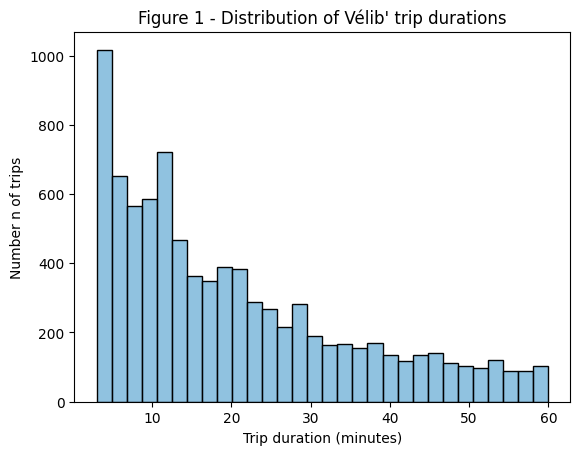

In [24]:
# Histogram
sns.histplot(
    data=df_trips_cleaned,
    x="duration_min",
    color="#6baed6",
    bins=30
)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Number n of trips")
plt.title("Figure 1 - Distribution of Vélib' trip durations")
plt.show()

The majority of Vélib’ trips last less than 20 minutes, with a sharp decrease in frequency as duration increases.

/var/folders/4h/l2qwrhwd5rn1fq7txjbb0mhw0000gn/T/ipykernel_5876/2563063001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


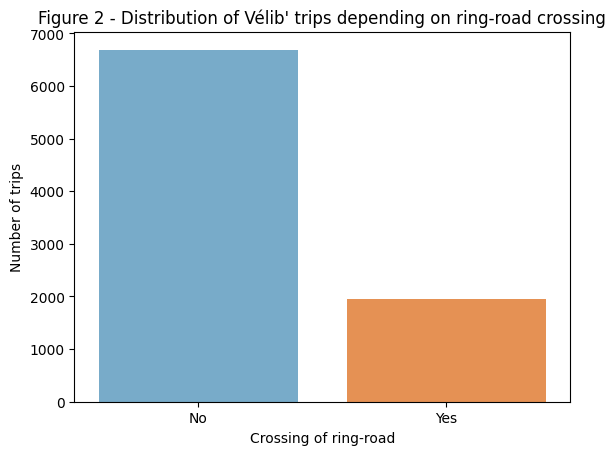

In [25]:
# Count plot
sns.countplot(
    data=df_trips_cleaned,
    x="ring_crossing",
    palette=["#6baed6", "#fd8d3c"],
)
plt.xlabel("Crossing of ring-road")
plt.ylabel("Number of trips")
plt.title("Figure 2 - Distribution of Vélib' trips depending on ring-road crossing")
plt.show()

Most Vélib' users remain inside or outside the Parisian ring-road, while a smaller proportion cross it during their trip.

### 6.3 Bivariate analysis

/var/folders/4h/l2qwrhwd5rn1fq7txjbb0mhw0000gn/T/ipykernel_5876/4198948835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


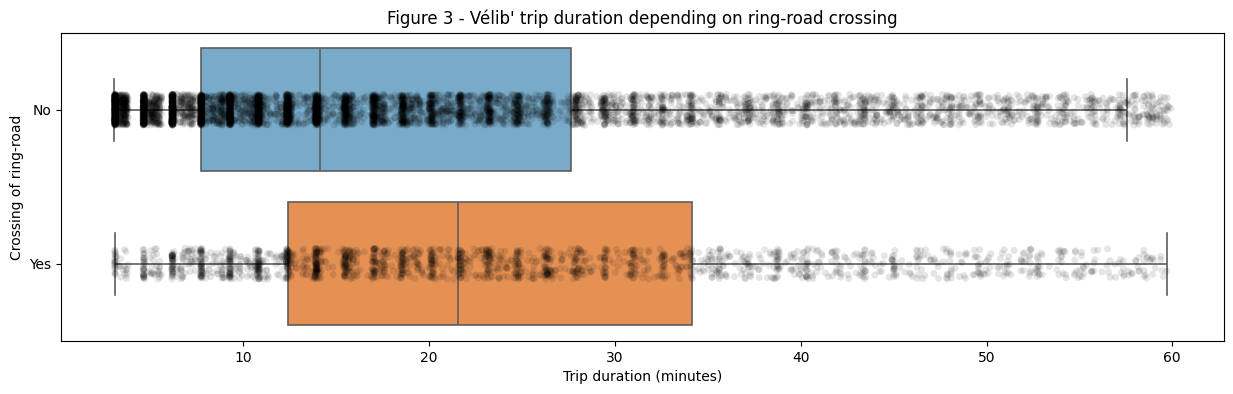

In [31]:
# Box plot

plt.figure(figsize=(15, 4))

sns.boxplot(
    data=df_trips_cleaned,
    y="ring_crossing",
    x="duration_min",
    orient="h",
    palette=["#6baed6", "#fd8d3c"],
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_trips_cleaned,
    y="ring_crossing",
    x="duration_min",
    orient="h",
    color="black",
    alpha=0.1,
    size=5,
    linewidth=0,
    edgecolor="none",
    jitter=True
)

plt.xlabel("Trip duration (minutes)")
plt.ylabel("Crossing of ring-road")
plt.title("Figure 3 - Vélib' trip duration depending on ring-road crossing")
plt.show()

Median, quartiles and whiskers are upper in the second boxplot than in the first one.

## 7. Conclusion

Trips that cross the ring road tend to be noticeably longer than those remaining within Paris (Figure 3).
It therefore seems that Vélib’ users crossing the périphérique usually undertake longer journeys, probably connecting suburban and central areas.

In future work, it would be interesting to examine whether trip duration decreases as we get closer to the city center, in order to see if the same spatial trend holds beyond the ring-road distinction.